# HW6 Retinal Vessel Segmentation

首先先處理環境

In [1]:
import tensorflow as tf
import os

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1'
print("Tensorflow Version: ", tf.__version__)
print(tf.config.list_physical_devices('GPU'))
print("Numbers of GPU Available: ", len(tf.config.list_physical_devices('GPU')))

2026-01-14 21:39:20.478681: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-01-14 21:39:20.484846: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768397960.493171 1589347 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768397960.495949 1589347 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768397960.502334 1589347 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Tensorflow Version:  2.19.1
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Numbers of GPU Available:  1


In [ ]:
import random
import numpy as np

def set_global_seed(seed=42):
    # 1. Python hash seed
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # 2. Python standard random
    random.seed(seed)
    
    # 3. Numpy random
    np.random.seed(seed)
    
    # 4. TensorFlow random
    tf.random.set_seed(seed)

    print(f"Global Seed Set to: {seed}")

set_global_seed(42)

Global Seed Set to: 42


## Section 1. Probability Space

在只有 16 張訓練影像的小樣本情況下，若不先釐清 **Probability Space 與 Statistical Inference** 的基礎，很容易陷入煉丹狀況

### Step A. Underlying Statistical Model

在眼底血管分割任務中，觀測對象實際上並不是整張圖片，而是圖片中的每一個 Pixel。因此這時候可以定義機率空間 $(\Omega, \mathcal{F}, P)$，其中

- Sample Space $\Omega$ 是所有可能出現的「像素特徵與標籤組合」的集合。對於一張輸入影像，每一個位置 $i$ 的數據對可以表示為 $\omega_i = (x_i, y_i)$。其中
    
    - $x_i \in \mathbb{R}^3$ 是 Pixel $i$ 的 RGB 數值   
    - $y_i \in \{0, 1\}$ 是 Pixel $i$ 的標籤

- Sigma-algebra $\mathcal{F}$ 是 $\Omega$ 的所有子集構成的集合，代表可以討論的所有可能事件。例如「綠色通道強度 > 100 且是血管」等事件
- Probability Measure $P$ 是一個未知的 Joint Probability Distribution $P(X, Y)$，代表自然界中眼底影像的像素特徵與其是否為血管的真實關係

現在的目標是，這 16 張訓練影像 $D_{train}$ 以及 4 張驗證影像 $D_{val}$ 是從這個真實分佈 $P(X, Y)$ 中獨立同分佈（i.i.d.）抽樣出來的樣本

### Step B. Define Probability Space

現在定義訓練資料是一個成對的集合 $D = \{(x_i, y_i)\}_{i=1}^N$，其中 $x_i$：輸入影像 `train_images/*.tif`、而 $y_i$ 是真實標籤 `train_masks/*.gif`。在物理上，這些檔案是分開存放的。在這情況下就要確保 $x_i$ 與 $y_i$ 的 Index Alignment，所以必須對檔案路徑進行排序，確保第 $i$ 張圖片對應到第 $i$ 張 Mask。如果沒有對齊，模型就會學習到錯誤的條件機率 $P(Y|X)$，導致訓練發散

In [3]:
import glob

BASE_DIR = 'hw6_retinal_vessel'

TRAIN_IMG_DIR = os.path.join(BASE_DIR, 'train_images')
TRAIN_MASK_DIR = os.path.join(BASE_DIR, 'train_masks')

VAL_IMG_DIR = os.path.join(BASE_DIR, 'valid_images')
VAL_MASK_DIR = os.path.join(BASE_DIR, 'valid_masks')

宣告好路徑之後，就下來就是要逐一對應

In [4]:
def get_file_paths(img_dir, mask_dir):
    img_paths = sorted(glob.glob(os.path.join(img_dir, '*.tif')))
    mask_paths = sorted(glob.glob(os.path.join(mask_dir, '*.gif')))
    
    if len(img_paths) != len(mask_paths):
        raise ValueError(f"Images ({len(img_paths)}) and Masks ({len(mask_paths)}) count mismatch!")
        
    return img_paths, mask_paths

隨後讀取路徑

In [5]:
train_img_paths, train_mask_paths = get_file_paths(TRAIN_IMG_DIR, TRAIN_MASK_DIR)
val_img_paths, val_mask_paths = get_file_paths(VAL_IMG_DIR, VAL_MASK_DIR)

print(f"Training samples: {len(train_img_paths)}")
print(f"Validation samples: {len(val_img_paths)}")

Training samples: 16
Validation samples: 4


## Section 2. Data Preprocessing

### Step A. Normalization

現在要定義從硬碟讀取影像資料的函數 $f_{read}: \text{Path} \to \mathbb{R}^{H \times W \times 1}$

由於眼底視網膜的影像中，紅色血管在綠色 Channel 的對比度最高，且為了對抗照明不均與低對比度問題，那就要先定義訊號增強流程：

1. 將原始 RGB 影像 $I_{raw} \in \mathbb{R}^{H \times W \times 3}$ 降維取其綠色分量 $I_{green}$
2. 應用 CLAHE $\Phi$ 用以強化血管邊緣的特徵

$$
I_{enhanced} = \Phi(I_{green})
$$

因為原始影像 $I_{raw}$ 的像素值通常在整數空間 $\mathbb{Z} \cap [0, 255]$，然而神經網路的最佳化過程（Gradient Descent）在數值範圍 $[0, 1]$ 且具有單位變異數時收斂最快。所以可以先定義一個 Normalization 函數 $N(x)$ 為

$$
N(x) = \frac{x}{255}
$$

主要用來將輸入空間映射到連續實數空間 $x \in \mathbb{R} \cap [0, 1]$，故最後的輸入為 $x = N(I_{enhanced})$

而對於 Mask（標籤 $y$），資料集的 GIF 檔通常包含 0（背景）與 255（血管）。需要將其轉化為二元指示變數（Indicator Variable）

$$
y_{binary} = \mathbb{1}(y_{raw} > 127)
$$

這樣 $y_{binary} \in \{0, 1\}$，符合 Bernoulli 分佈的參數定義

由於 `*.tif` 和 `*.gif` 在某些 TensorFlow 版本中的解碼支援度不一，因此使用 `tf.py_function` 包裝 Python 的 PIL 或 cv2 庫來讀取

In [6]:
from PIL import Image
import cv2

def load_data_py(img_path, mask_path):

    img = Image.open(img_path.numpy())
    img = np.array(img) # (H, W, 3)
    
    # Green Channel (Index 1) + CLAHE
    img_g = img[:, :, 1] 
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    img_enhanced = clahe.apply(img_g)
    
    # (H, W, 3) -> (H, W, 1) & Normalization
    img_final = np.expand_dims(img_enhanced, axis=-1)
    img_final = img_final.astype(np.float32) / 255.0
    # ------------------------------------
    
    # Masking
    mask = Image.open(mask_path.numpy())
    mask = np.array(mask)
    if mask.ndim == 2:
        mask = np.expand_dims(mask, axis=-1)
    mask = mask.astype(np.float32) / 255.0
    mask = (mask > 0.5).astype(np.float32)
    
    return img_final, mask

Python 的原生函式庫如 PIL 或 cv2 等，通常無法被直接編譯，因此直接在 `dataset.map` 中呼叫 `load_data_py`，那程式會因為無法將 Python 物件轉換為 Tensor Graph 操作而出現錯誤。因此要讓 TensorFlow 執行到 `load_data_py` 時就先切換到 Python 直譯器中執行，在拿到結果後再轉回 Tensor 格式繼續跑

1. 這樣可以定義 `load_data_tf`，其中 `inp` 是指定輸入參數，均為 Tensor；而 `Tout` 則是輸出資料型態，必須與 `load_data_py` 的回傳（`float32`）一致
2. 隨後要修補形狀資訊。因為經過 `py_function` 後，TensorFlow 會遺失形狀資訊，因此要使用 `set_shape` 讓 TensorFlow 知道這些 tensor 的維度。要注意這裡設為 None 的原因是圖片長寬還是原始的 `565x584`，尚未統一；而兩個 `1` 則分別代表 CLAHE 通道與 Mask 通道，這是確定的

In [7]:
def load_data_tf(img_path, mask_path):
    img, mask = tf.py_function(
        func=load_data_py,
        inp=[img_path, mask_path],
        Tout=[tf.float32, tf.float32]
    )
    img.set_shape([None, None, 1]) # CLAHE, 1 Channel
    mask.set_shape([None, None, 1])
    return img, mask

### Step B. Random Crop and Data Augmentation

這裡要採用 Subspace Sampling，也就是說原始影像尺寸 $565 \times 584$ 不能被 $2^n$ 整除，這時如果直接訓練整張圖，參數量就會肥大且樣本僅 16 個。這時候可以定義一個隨機裁切運算 $C(x, y)$，從原始空間 $\Omega$ 採樣出一個子空間 $\Omega_{sub}$

$$
x_{crop}, y_{crop} = C(x, y; h, w), \quad \text{where } h = 256,\; w = 256
$$

這在數學上有三個好處：

1. 一張 $565 \times 584$ 的圖可以透過 flip 與 Rotate 而產生數百個不同的 $256 \times 256$ 局部視圖，可以做到樣本多樣性
2. 透過旋轉可以強迫模型關注「局部紋理」而非整張圖的「宏觀位置」
3. 透過引入隨機 Photometric Augmentation，即讓 $I' = \text{clip}(\alpha I + \beta)$ 用以強迫模型學習血管的拓樸結構，而非死記 CLAHE 產生的特定灰階值

因此實做上就要建立 `tf.data` Pipeline 加入 Random Crop 操作。要注意的是 Image 與 Mask 在這情況下是一對一關係，因此要拼接在一起裁切，才能保證位置可以對應而不跑掉

In [8]:
IMG_SIZE = 256

def process_pipeline(img_path, mask_path):
    
    # 0. Load
    img, mask = load_data_tf(img_path, mask_path)
    
    # 1. Crop
    combined = tf.concat([img, mask], axis=-1)
    combined_crop = tf.image.random_crop(combined, size=[IMG_SIZE, IMG_SIZE, 2])
    
    # 2. Rotate
    if tf.random.uniform(()) > 0.5:
        combined_crop = tf.image.flip_left_right(combined_crop)
    if tf.random.uniform(()) > 0.5:
        combined_crop = tf.image.flip_up_down(combined_crop)
        
    img_crop = combined_crop[:, :, :1]
    mask_crop = combined_crop[:, :, 1:]
    
    # 3. Augmentation
    img_crop = tf.image.random_brightness(img_crop, max_delta=0.2) # beta
    img_crop = tf.image.random_contrast(img_crop, lower=0.8, upper=1.2) # alpha
    img_crop = tf.clip_by_value(img_crop, 0.0, 1.0) # clip s.t. I' = [0, 1]
    
    return img_crop, mask_crop

現在就可以建立 Dataset 物件

In [9]:
BATCH_SIZE = 8
BUFFER_SIZE = 1000

train_dataset = tf.data.Dataset.from_tensor_slices((train_img_paths, train_mask_paths))
train_dataset = train_dataset.map(process_pipeline, num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

I0000 00:00:1768397962.273602 1589347 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6058 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4070 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


但在處理驗證集時，通常不做 Random Crop，然而因為尺寸問題，可以透過填充處理。也就是說，資料集的原始尺寸為 $565 \times 584$，那為了讓經過 Pooling 的模型能順利運算，長寬最好能被 $2^n$ 整除。這裡不縮放圖片，而是將其填充至最接近且較大的 16 倍數尺寸，即 $592 \times 592$。這樣可以在保留 1:1 的原始解析度之下，又同時符合 U-Net 的維度需求

In [ ]:
TARGET_SIZE = 592 # 16*37

def validate_pipeline(img_path, mask_path):

    img, mask = load_data_tf(img_path, mask_path)
    
    img = tf.image.pad_to_bounding_box(img, 0, 0, TARGET_SIZE, TARGET_SIZE)
    mask = tf.image.pad_to_bounding_box(mask, 0, 0, TARGET_SIZE, TARGET_SIZE)
    
    return img, mask

函數 `validate_pipeline` 定義好之後，就可以用來建立 validation 資料集

In [11]:
val_dataset = tf.data.Dataset.from_tensor_slices((val_img_paths, val_mask_paths))
val_dataset = val_dataset.map(validate_pipeline, num_parallel_calls=tf.data.AUTOTUNE)
val_dataset = val_dataset.batch(1).prefetch(tf.data.AUTOTUNE)

## Section 3, Define the Model

### Step A. Convolution Block

在 Convolution Block 中會採用 Conv2D -> Batch Normalization -> Relu 的操作，對應到「線性變換 -> 空間校正 -> 非線性切分」的操作

```python
x = layers.Conv2D(filters, (3, 3), padding="same", kernel_initializer="he_normal")(x)
x = layers.BatchNormalization()(x)                                                    
x = layers.Activation("relu")(x)
```

原理是，

1. Basis Projection

    輸入的圖片像是原始 RGB 座標系，而給定 $k$ 個 filters，代表試圖尋找 $k$ 個基底向量來行程一個新的子空間 $V_{out}$。如果設定 `filters=16` 即代表 $k=16$，代表會尋找 16 個基底向量來構成 $V_{out}$。這時候原始圖片就會被 Project 到這 16 個方向上。其中一個基底可能長得像「垂直線」、另一個像「水平線」、可能還有粗細、分岔等情況
    
    在 $\mathbb{R}^{3 \times 3}$ 的空間中，先假設描述血管邊緣所需的 主成分（Principal Components） 數量不超過 16 個， **可以視情況調整**。但如果設為過高數值如 64 或 128，會導致 Basis Redundancy，這時矩陣 $W$ 會變得由線性相依的向量組成（Low Rank），浪費計算資源且易過擬合。那在這個運算後，就會得到一個特徵圖，但這純粹是線性的

2. Coordinate Realignment

    可以注意到 `kernel_initializer="he_normal"`，這是因為深度神經網路的訓練本質是矩陣連乘，若權重矩陣 $W$ 的奇異值（Singular Values）分佈不均，會導致 Hessian 矩陣的條件數（Condition Number, $\kappa$） 惡化

    $$
    \kappa(H) = \frac{|\lambda_{max}|}{|\lambda_{min}|}
    $$

    那 Batch Normalization (BN) 做的事情是將每一層的輸出 $x$ 重新做 z-score 並縮放。操作 BN 的主要原因就是經過 Conv2D 投影後，資料的分佈可能會亂跑，例如某個方向的值特別大，變成 1000，另一個只有 0.1，這會讓這個空間的幾何形狀變成細長的橢圓，這時過大的 $\kappa(H)$ 就會導致梯度下降出現 oscillate，畢竟 Condition Number 很差。因此操作 BN 的主要目標就是將每一層的輸出 $x$ 重新做 z-score 並縮放，讓資料的分佈更接近常態分布：

    $$
    \hat{x} = \frac{x - \mu}{\sqrt{\sigma^2 + \epsilon}} \cdot \gamma + \beta
    $$

    換句話說就是試圖將每一層輸入的 Covariance Matrix $Cov(x)$ 強制調整為接近單位矩陣 $I$ 的狀態，用來保證
    
    - 減少 Hessian Spectrum 中的 outlier eigenvalues，讓整體條件數比較不會惡化得太快
    - BN 有助於讓 activation 值（而非權重）在某些條件下出現比較完整的正交性質

3. Non-linearity

    畢竟在數學上，疊了一萬層 Conv2D 也是等價於只做一層矩陣連乘 $W_2 W_1 = W_{new}$。因此操作 ReLU 的目的是把負值歸零，這相當於在空間中進行「摺疊」或「切分」，模型就有能力去描述非線性的形狀，例如血管彎彎曲曲的邊緣

但這通常會做 Double Convolution，這也是 U-Net 的操作。有兩個原因

1. Receptive Field

    因為單個 $3 \times 3$ convolution kernel 只能看到周圍 1 格的 pixel，對於判斷一條血管的走向來說視野太窄會看不出脈絡。如果使用 Double Convolution，那就會是

    - 第一層看原始圖片的 $3 \times 3$
    - 第二層看第一層的 $3 \times 3$

    這樣 receptive field 就會是兩層 $3 \times 3 + 3 \times 3 = 18$ 可以達到 $5 \times 5 = 25$ 的視野，且參數量更少

2. Rank

    - 單次操作只是把 RGB 轉成 16 維特徵後做一次空間切分，這樣可能只能分出例如「哪裡有顏色差異」這種基礎特徵
    - 兩次操作的第二層卷積是在「第一層已經提取出的特徵」基礎上進行組合，即
    
        $$
        y = \sigma(W_2 \cdot \sigma(W_1 \cdot x))
        $$
    
        例如：第一層找到了「橫線」和「直線」。第二層可以透過組合這兩個基底，辨識出「十字交叉」或「轉角」。若從 Rank 的角度來看，單層 $W_1$ 只能做仿射變換；疊加到 $W_2$ 就可以增加變換的複雜度，用以確保特徵空間的 Effective Rank 足夠高，能將「血管」與「背景」這兩個糾纏在一起的集合在高維空間中區分開來

綜合以上，可以定義 `conv_block` 為

In [12]:
def conv_block(x, filters):

    # Linear Transformation -> Batch Normalization -> Nonlinear Segmentation
    x = layers.Conv2D(filters, (3, 3), padding="same", kernel_initializer="he_normal")(x) # W1
    x = layers.BatchNormalization()(x)                                                    # BN
    x = layers.Activation("relu")(x)                                                      # σ
    
    # Increase the Effective Rank.
    x = layers.Conv2D(filters, (3, 3), padding="same", kernel_initializer="he_normal")(x) # W2
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    return x # such that y = σ(W_2*(σ( W_1*x)))

### Step B. Shallow U-Net

有了 `conv_block` 這個基礎運算單元後，Shallow U-Net 的組裝本質上是在處理訊號的 Dimensionality Transformation 與 Information Flow Preservation。這裡主要就四個機制：分別為 Encoder（Down sampling）、Decoder（Up sampling）、Skip Connection 以及位於底層的 Bridge（Dropout）：

1. Encoder for Spatial Rank Compression

    在編碼路徑中通常會交替使用 `conv_block` 與 `MaxPooling2D`：

    $$
    x_{l+1} = \text{Pool}(\Phi(x_l))
    $$

    其中 $\Phi$ 是 conv_block 的非線性變換。因為 `MaxPooling` 是一個不可逆的降維操作，這時假設輸入特徵圖 $X \in \mathbb{R}^{H \times W}$，經過 $2 \times 2$ 池化後變為 $X' \in \mathbb{R}^{\frac{H}{2} \times \frac{W}{2}}$。
這在數學上相當於丟棄 $75\%$ 的空間資訊（高頻訊號，如精確的血管邊緣位置），以換取更大的 Receptive Field 與低頻訊號（抽象語義特徵，如血管的存在區域）

2. Decoder for Inverse and Nullspace

    解碼路徑就是試圖將低解析度的特徵 $z$ 恢復回原始解析度 $y$

    $$
    y = \text{UpSample}(z)
    $$

    單純的 Up Sampling 無論是 Nearest Neighbor 或 Bilinear Interpolation，都只是將現有的資訊做複製或插值（顧名思義）。在線性代數中，這是一個稀疏矩陣運算，數學上並無法憑空產生資訊。因為 Encoder 階段丟棄的資訊已經落入了變換矩陣的 Null Space $\mathcal{N}(A)$，所以單純靠 Decoder 根本無法從 $\mathcal{N}(A)$ 中找回那些遺失的邊緣細節。這就是為什麼缺乏 Skip Connection 的 AutoEncoder 輸出的血管邊緣總是模糊的

3. Skip Connection for Rank Injection

    續上，這裡就是要解決 Decoder 的 Null Space 問題。這裡會將 Encoder 同一層級中還沒被 Pooling 破壞的特徵圖 $C$ 與 Decoder 上採樣後的特徵圖 $U$ 進行 Concatenate

    $$
    Z = [U \mid C]
    $$

    其中 
    - $\text{Rank}(Z) \approx \text{Rank}(U) + \text{Rank}(C)$
    - $U$ 提供的是 語義資訊，例如「這裡大概是血管」
    - $C$ 提供的是 空間資訊，例如「這裡有高頻的邊緣訊號」

    所以 Concatenate 就是強制將 Encoder 保留但那些原本在 Decoder 看不到的 Null Space 內容的高頻資訊注入回模型中，讓後續的 `conv_block` 有能力在全解析度上重新計算精確的邊界

4. Bridge and Dropout for Bayesian Approximation

    在 Encoder 與 Decoder 的交界處可以引入 Dropout 機制，這是因為眼底血管資料集僅 20 張，模型在小樣本狀態下很容易出現 Overfitting，即直接背誦 CLAHE 增強後的特定灰階紋理，而非學習血管的拓樸結構。而 Dropout 可以解決這問題的原理如下：

    - 透過隨機遮蔽神經元來強迫模型不能依賴單一特徵路徑，必須建立多條冗餘路徑來辨識血管拓樸結構
    - 在訓練過程中，每一次 Iteration 的網路結構都不同，在數學上等價於訓練 $2^n$ 個共享權重的子神經網路並取其平均，即 Ensemble Learning。這樣就可以降低估計的 Variance，使模型對未見過的血管紋理比較有學習能力

根據以上，可以實作一個 `Depth=3` 且兩次下採樣的 Shallow U-Net：

In [13]:
from tensorflow.keras import layers, models, Input

def build_shallow_unet(input_shape=(None, None, 1), start_filters=16):
    inputs = Input(shape=input_shape)

    # Encoder, Rank = 16
    c1 = conv_block(inputs, start_filters)
    p1 = layers.MaxPooling2D((2, 2))(c1)

    # Encoder, Rank = 32
    c2 = conv_block(p1, start_filters * 2)
    p2 = layers.MaxPooling2D((2, 2))(c2)

    # Bridge with Dropout, Rank = 64
    c3 = conv_block(p2, start_filters * 4)
    d3 = layers.Dropout(0.5)(c3) 

    # Decoder, Rank = 32
    u2 = layers.UpSampling2D((2, 2))(d3) 
    u2 = layers.Concatenate()([u2, c2])
    c4 = conv_block(u2, start_filters * 2)

    # Decoder, Rank = 16
    u1 = layers.UpSampling2D((2, 2))(c4)
    u1 = layers.Concatenate()([u1, c1])
    c5 = conv_block(u1, start_filters)

    outputs = layers.Conv2D(1, (1, 1), activation="sigmoid")(c5)
    model = models.Model(inputs, outputs, name="Shallow_UNet_Dropout")

    return model

這時候就可以驗證模型結構

In [14]:
model = build_shallow_unet(input_shape=(None, None, 1))
model.summary()

Model: "Shallow_UNet_Dropout"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 1)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, None,      │        160 │ input_layer[0][0] │
│                     │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, None,      │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, None,      │      2,320 │ activation[0][0]  │
│                     │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, None,      │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ None, 16)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, None,      │      4,640 │ max_pooling2d[0]… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, None,      │      9,248 │ activation_2[0][… │
│                     │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, None,      │          0 │ batch_normalizat… │
│ (Activation)        │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, None,      │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ None, 32)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, None,      │     18,496 │ max_pooling2d_1[… │
│                     │ None, 64)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, None,      │        256 │ conv2d_4[0][0]  

 Total params: 119,265 (465.88 KB)

 Trainable params: 118,625 (463.38 KB)

 Non-trainable params: 640 (2.50 KB)

### Step C. Loss Function

這裡會使用 Dice Loss，因為 Keras 預設的 `binary_crossentropy` 是在算最大概似估計量（MLE），在這情況下由於血管與背景的像素比例極度不平衡。由於背景的比例大約佔了 90%，也就是說背景的 Prior Probability 大約為 0.9 會遠大於血管，而致損失函數的梯度下降方向被多數類別主導，使模型收斂至一個 trivial solution。換句話說就是預測所有像素皆為背景。此時雖然 Accuracy 可達 90%，但模型會沒辦法學習到條件機率 $P(Y=1|X)$ 而陷入 local minima。而 Dice Coefficient 在統計上定義為 Precision 與 Recall 的調和平均數

$$
Dice = \frac{2 |Y_{true} \cap Y_{pred}|}{|Y_{true}| + |Y_{pred}|}
$$

為了配合梯度下降法進行參數最佳化，可以將其從離散集合推廣至連續機率空間，定義 Soft Dice 如下：

$$
Dice(y, \hat{y}) = \frac{2 \sum_i y_i \hat{y}_i + \epsilon}{\sum_i y_i + \sum_i \hat{y}_i + \epsilon}
$$

其中 $\sum y_i \hat{y}_i$ 代表兩分佈的交集期望值、分母則為兩集合的 Cardinality；$\epsilon$ 是 Laplace Smoothing，用來避免出現除以 0 的狀況，也就是防止當預測全黑且真實全黑時，同時也是防止梯度消失或梯度爆炸

In [15]:
from tensorflow.keras import backend as K

def dice_coef(y_true, y_pred):

    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    smooth = 1e-5

    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

若要讓 Dice 最大，但同時 Gradient Descent 是最小，所以定義：

$$
L_{Dice} = 1 - Dice(y, \hat{y})
$$

In [16]:
def dice_loss(y_true, y_pred):
    return 1.0 - dice_coef(y_true, y_pred)

然而，單純使用 Dice Loss 有時會導致梯度不穩定。這是因為 Dice Loss 的定義為 $L = 1 - \frac{2I}{U}$，其中 $I$ 是交集，$U$ 是聯集（分母 $\sum y + \sum \hat{y}$）

當對預測值 $\hat{y}$ 進行微分以求梯度時，根據 Quotient Rule，分母 $U$ 會變成 $U^2$ 使得

$$
\frac{\partial L}{\partial \hat{y}} \propto \frac{1}{(\sum y + \sum \hat{y})^2}
$$

這樣就會出現問題了。因為在血管分割任務中，前景（血管）像素極少，這導致分母 $U$ 的數值原本就很小。當分母被平方後，數值會變得非常小。最大問題就在，當預測目標很小時，預測值 $\hat{y}$ 的微小改變，會導致 Loss 產生明顯振盪使得梯度更新非常不穩定，換來的結果就是模型訓練初期就難以收斂，會在 Optimal 處反覆橫跳反覆橫跳

所以解決這 issue 的方式就是引入 Weighted BCE，讓透過給予正樣本（血管）一個懲罰權重 $w$，強迫模型注意到較為稀疏的血管像素，即

$$
L_{WBCE} = - \left( w \cdot y \log(\hat{y}) + (1-y) \log(1-\hat{y}) \right)
$$

最後 Loss 總和是兩者的和，其中設定 $w=5$ 配合 CLAHE 增強後的訊號強度

$$
L_{total} = L_{WBCE} + L_{Dice}
$$

實做如下

In [17]:
def weighted_bce_dice_loss(y_true, y_pred):

    pos_weight = 5.0 
    epsilon = 1e-7
    y_pred = K.clip(y_pred, epsilon, 1. - epsilon)
    
    # Weighted BCE
    loss_bce = - (pos_weight * y_true * K.log(y_pred) + (1. - y_true) * K.log(1. - y_pred))
    loss_bce = K.mean(loss_bce)
    
    # Dice Loss
    loss_dice = dice_loss(y_true, y_pred)

    return loss_bce + loss_dice

### Step D. Optimizers, Callbacks, and Compile

#### Step D.1 Optimizer

因為現在要處理的是高維度 Non-convex Optimization 與 Sparse Gradients 的問題，Optimizer 上會使用 Adam。理由如下

1. Loss Landscape 在處理「背景」訊號時的下降會非常快（因為很好估計），但是在處裡「微血管」這類時下降就很慢。這樣就會讓 Hessian 的 Condition Number $\kappa$ 變得很大
2. 因為這種小訓練集會使用 `Batch Size = 8` 的小批量訓練，這樣估計出的隨機梯度 $g_t$ 是真實梯度 $\nabla L(\theta)$ 中，帶有高變異數的有偏估計量

因此使用 Adam 可以從兩個狀態變數來處理這問題，也就是對梯度進行 Exponential Moving Average 的估計

1. Signal Smoothing 是當梯度方向充斥著隨機雜訊時，可以透過累積歷史動量可以抵消隨機振盪，保留主要的下降方向

    $$
    m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t
    $$

    其中 $m_t$ 是梯度的期望值 $E[g_t]$ 的估計


2. Adaptive Scaling 則是

    $$
    \theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t
    $$

    其中 $v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$ 是梯度平方的期望值 $E[g_t^2]$ 的估計，近似於 non-zero-centered 變異數。分為兩種狀況：

    1. 對於頻率高、梯度大的參數（例如背景特徵），$v_t$ 很大，導致學習率 $\frac{\eta}{\sqrt{v_t}}$ 自動變小，從而穩定收斂
    2. 對於頻率低、梯度小的參數（例如微血管特徵），$v_t$ 很小，導致學習率 $\frac{\eta}{\sqrt{v_t}}$ 自動變大，從而加速學習效率

在此先將 Learning Rate 設定為 $10^{-3}$

In [18]:
LEARNING_RATE = 1e-3

optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

#### Step D.2 Callbacks

那實務工程上不能盲目跑數百個 epochs，會需要

1. `ModelCheckpoint` 只儲存 Validation Loss 最低的模型，即 Best Only
2. `EarlyStopping` 是如果 Validation Loss 在連續 25 個 epochs 沒下降，就直接停止訓練，避免浪費 GPU 算力資源
3. `ReduceLROnPlateau` 是如果 Validation Loss 在連續 10 個 epochs 沒下降，就降低學習率，避免過度訓練。最小值為 $10^{-6}$
4. `CSVLogger` 可以將訓練結果儲存成 CSV 檔案

In [19]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        'weighted_bce_dice_loss.h5', 
        verbose=1, 
        save_best_only=True, 
        monitor='val_dice_coef', 
        mode='max'
    ),
    tf.keras.callbacks.EarlyStopping(
        patience=25, 
        monitor='val_loss', 
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=10, 
        min_lr=1e-6, 
        verbose=1
    ),
    tf.keras.callbacks.CSVLogger(
        'hw6_training_log.csv', 
        separator=',', 
        append=False
    )
]

#### Step D.3 Compile

這裡會同時監控以下四種指標

1. `dice_coef` 為 Precision 與 Recall 的調和平均，即幾何集合的相似度
2. `binary_crossentropy` 關注的是 pixel 機率的信心。有時候幾何相似度夠高讓 Dice 很高，但同時也讓 BCE 很高。這情況就是模型雖然正確找出血管位置，但對自己的預測很猶豫，例如預測值都在剛好過閾值的 0.51 邊緣徘徊，這是一個警訊代表模型不夠穩定
3. `Precision` 是抓 Type I Error / False Positive，也就是在所有被模型預測為血管的像素中，有多少是真的血管？畢竟有些雜訊可能看起來像是血管
4. `Recall` 是抓 Type II Error / False Negative，也就是在所有真的血管像素中，有多少被模型抓到了？畢竟大的血管很好抓，但微血管常被漏掉

In [20]:
model.compile(
    optimizer=optimizer, 
    loss=weighted_bce_dice_loss,
    metrics=[
        dice_coef, 
        'binary_crossentropy', 
        tf.keras.metrics.Precision(), 
        tf.keras.metrics.Recall(),
    ],
)

### Step E. Execution

現在就可以將 Dataset、模型架構（Shallow U-Net）與最佳化目標（Dice Loss）結合在一起

In [ ]:
EPOCHS = 500 

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=2
)

# The output is cleared and is stored in `chw6_training_log.csv`
# , where best epoch is 304 with Validation Result: 
#   Loss 0.48562 / Recall 0.88217 / Precision 0.70658 / Dice 0.71302

## Section 4. Evaluation the Result

### Step A. Loss and Dice Curve

訓練完後，第一件事不是看預測圖，而是檢查 Loss Curve

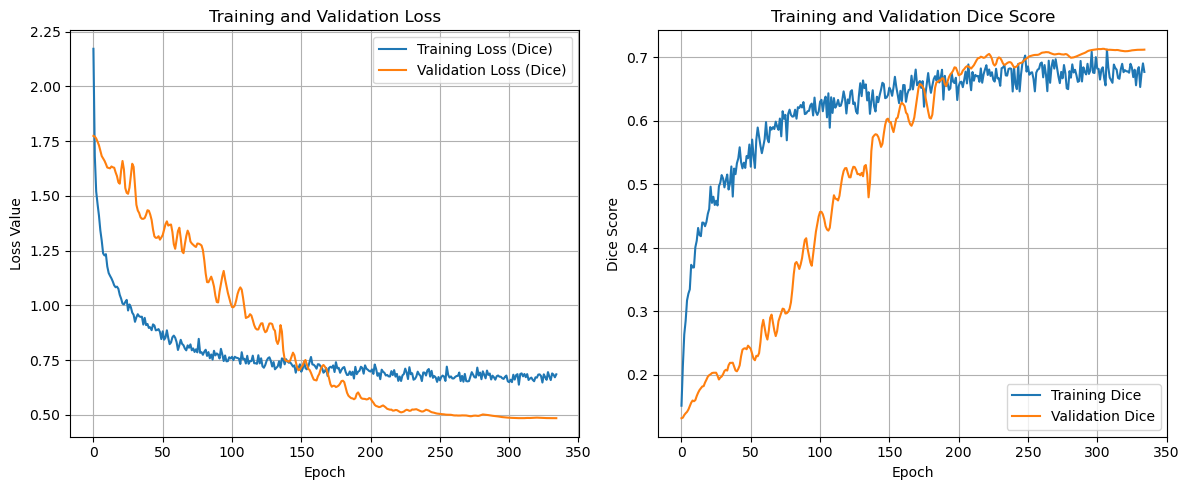

In [22]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']
dice = history.history['dice_coef']
val_dice = history.history['val_dice_coef']

epochs_range = range(len(loss))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Loss Curve
ax1.plot(epochs_range, loss, label='Training Loss (Dice)')
ax1.plot(epochs_range, val_loss, label='Validation Loss (Dice)')
ax1.set_title('Training and Validation Loss')
ax1.legend(loc='upper right')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss Value')
ax1.grid(True)

# Plot 2: Dice Coefficient Curve
ax2.plot(epochs_range, dice, label='Training Dice')
ax2.plot(epochs_range, val_dice, label='Validation Dice')
ax2.set_title('Training and Validation Dice Score')
ax2.legend(loc='lower right')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Dice Score')
ax2.grid(True)

plt.tight_layout()
plt.show()

觀察 Loss Curve 與 Dice Score 的變化軌跡，訓練過程呈現出顯著的三階段特徵，可以看出 `Dropout(0.5)` 與 `Weighted BCE` 的機制：

1.  在 Epoch 1-100 過程中，可以注意到 Val Loss 從 1.77 振盪下降到 0.97；同時 Dice Score 從 0.13 漲到僅至 0.46
    
    這代表模型正在對抗強烈的 Regularization，因為 Dropout 隨機關閉 50% 的神經元，導致 Loss Surface 的表面有很多雜訊。模型在這階段主要學習的是 **如何對抗背景權重**，即試圖在 `pos_weight=5` 的懲罰下找出視網膜大致上的輪廓，這時並抓不到血管細節。而振盪是 SGD 在尋找 global minima 時的正常行為

2.  在 Epoch 101-200 可以注意到 Val Loss 的下降速率趨緩，僅從 1.0 -> 0.6；但 Val Dice 突破 0.5 到 0.64

    也就是說模型已成功逃離「全猜背景」的 Local Minima，開始學習到血管的幾何 topology，因此 Dice Score 提升，讓 Recall 在此階段維持在 0.8 以上，顯示模型正在低 Precision 高 Recall 的階段，即 **容忍 Type-I Error（誤判）且嚴禁 Type-II Error（漏診）**，符合臨床醫療影像分割需要的高檢定力 $1 - \beta$ 需求

3.  在 Epoch 201-334 已經開始觸發多次 `ReduceLROnPlateau`，學習率從 $10^{-4}$ 降至 $10^{-5}$ 級別，同時 Val Dice 在 Epoch 250 後穩定在 0.70 上下、在 Epoch 304 達 0.7115 峰值（考慮 `val_loss`）。隨後 Precision 開始下滑

    值得注意的是，在這階段的 **Precision 穩定維持在 0.70 左右，而 Recall 則進一步推升至 0.88**。這代表在 Weighted BCE（`pos_weight=5`）的設定下，模型在微調階段趨於偏向 Sensitivity 的分割策略。由於 Dice Coefficient 是 Precision 與 Recall 的調和平均數，當 Recall 在 Precision 固定之下逐漸提升時，就同時帶動 val 的 Dice Score 提升

### Step B. Probability Distribution, ROC, and Precision/Recall Curve

在訓練過程中的 Loss 與 Dice 僅提供了模型在特定閾值（通常是 0.5）下的單點性能狀況，並不能完整反映模型在所有閾值下的表現。所以現在要做的事情就是檢查模型的鑑別能力，然後找出最佳工作點。這情況就會需要看模型整體的機率分佈

首先要將所有驗證影像的 Mask $y$ 與預測機率 $\hat{y}$ 從二維空間 $(H, W)$ 展平並聚合為一維向量。這裡假定每一個像素點都是一個獨立的 Bernoulli Trial 樣本，因此能將將語義分割問題轉化為標準的二元分類問題，這樣做的目的在於可以計算全域指標。若僅計算單張影像的 ROC 再取平均，會忽略不同影像間難易度的變異度；因此將所有像素混合在一起計算，才能真實反映模型對整體資料分佈的排序能力

In [23]:
val_masks = []
val_preds = []

for img, mask in val_dataset:
    pred = model.predict(img, verbose=0)
    val_masks.extend(mask.numpy().flatten())
    val_preds.extend(pred.flatten())

val_masks = np.array(val_masks)
val_preds = np.array(val_preds)

2026-01-14 20:23:32.067233: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


有了全域的一維機率向量後，利用 sklearn 計算兩條關鍵曲線

1. ROC Curve 用來描述 $TPR$ (Recall) 與 $\text{FPR} = 1 - \text{Specificity}$ 之間，評估模型將正（血管）負（背景）樣本分開的能力。由於本案的負樣本比例很高，這時 FPR 容易維持在低檔，導致 ROC AUC 產生虛高的樂觀估計
2. PR Curve 用來描述 Recall 與 Precision 之間的關係，用來揭露模型是否為了衝高 Recall 而犧牲了過多的 Precision （把雜訊判斷成血管）

In [24]:
from sklearn.metrics import roc_curve, auc, precision_recall_curve

fpr, tpr, _ = roc_curve(val_masks, val_preds)
roc_auc = auc(fpr, tpr)

precision, recall, _ = precision_recall_curve(val_masks, val_preds)
pr_auc = auc(recall, precision)

在 Histogram、ROC、PR 都輸出之後，就可以作圖了

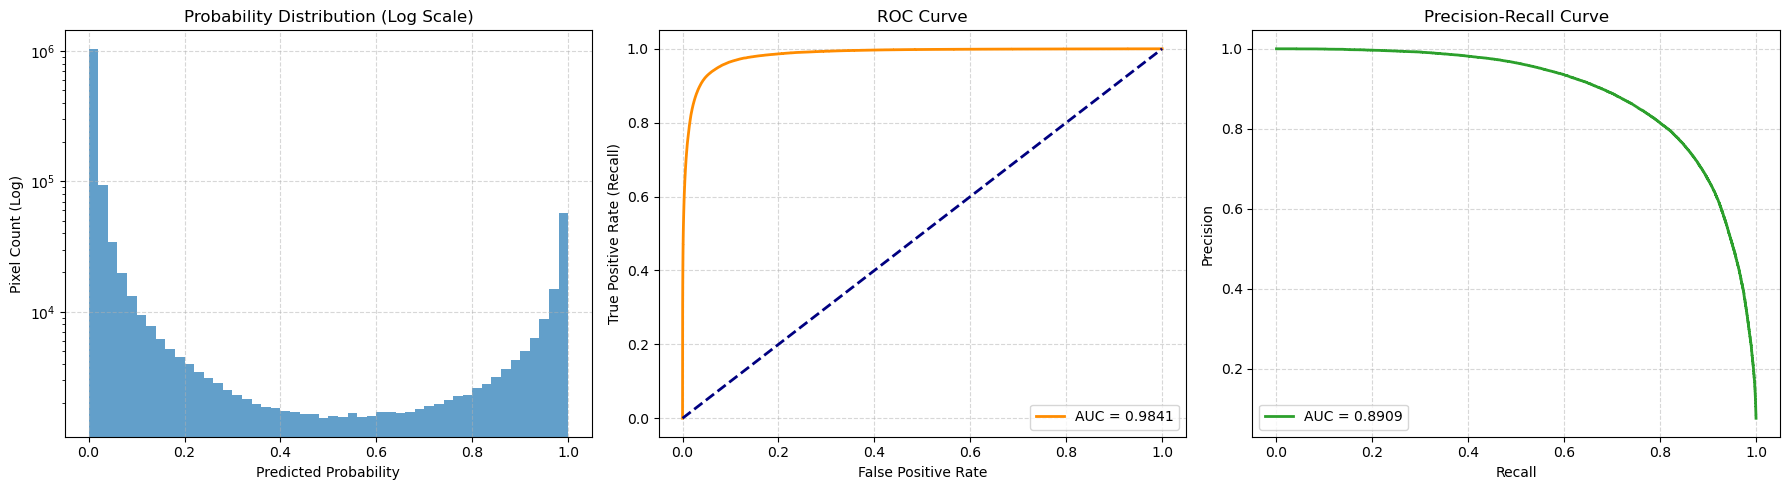

In [25]:
from sklearn.metrics import f1_score

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Probability Histogram
ax1.hist(val_preds, bins=50, color='tab:blue', alpha=0.7, log=True)
ax1.set_title('Probability Distribution (Log Scale)')
ax1.set_xlabel('Predicted Probability')
ax1.set_ylabel('Pixel Count (Log)')
ax1.grid(True, linestyle='--', alpha=0.5)

# Plot 2: ROC Curve
ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'AUC = {roc_auc:.4f}')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_title('ROC Curve')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate (Recall)')
ax2.legend(loc="lower right")
ax2.grid(True, linestyle='--', alpha=0.5)

# Plot 3: PR Curve
ax3.plot(recall, precision, color='tab:green', lw=2, label=f'AUC = {pr_auc:.4f}')
ax3.set_title('Precision-Recall Curve')
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.legend(loc="lower left")
ax3.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

1. **Probability Distribution in Log Scale** 回答「模型是猶豫不決，還是果斷判斷？」

    可以注意到機率分佈是 Bimodal Distribution，也就是說絕大多數的背景像素壓制在 0.0 附近，而血管像素則集中在 1.0 附近，這代表模型在判斷時是相當 confident 的，比較少有模糊地帶

    這正是 `pos_weight=5` 加上 Binary Cross Entropy 的結果。因為 BCE 的數學特性就是會懲罰預測值落在 0.5 附近的模糊地帶，強迫預測值往兩端（`0` 或 `1`）靠攏；而加權權重則是讓血管像素（右側）不會被龐大的背景的比例而淹沒，所以可以出現右側的峰值

2. **Receiver Operating Characteristic (ROC) Curve** 回答「模型全域的分辨能力如何？」

    `AUC = 0.9841` 是相當高的數值，也就是說曲線幾乎貼著左上角呈現直角轉折。其中 ROC 的 X 軸是 FPR（False Positive Rate），因為背景像素總數（分母）相當大，所以就算模型誤判很多背景雜點（FP），FPR 的數值依然會很小。換句話說，這張圖可以證明模型沒有爛掉，但是仍不足以證明模型在細節上的準確度


3. **Precision-Recall (PR) Curve** 回答「在『血管類別』這重點上，模型表現如何？」

    `AUC = 0.8909` 對於 Shallow U-Net 來說已經接近 SOTA。可以注意到

    - Recall 在 0.0 到 0.6 之間時，Precision 維持在接近 1.0 的高檔，也就是說模型對於主要血管幾乎沒有誤判
    - Recall 達到 0.8 左右 時，Precision 開始出現明顯下滑，也就是模型為了抓到較為細微的末梢血管（提升 Recall），開始得將一些背景雜訊也圈進來（犧牲 Precision）

    這時候在 CSV 中的 `Validation Loss 0.48562 / Recall 0.88217 / Precision 0.70658 / Dice 0.71302` 也證明 Weighted BCE 並非單純直接犧牲 Precision，而是讓模型趨於 Sensitivity（Recall）的邊界

那現在就可以透過在 $[0.1, 1.0]$ 區間內進行掃描，以 Dice Score（F1）為指標來尋找最佳的 Binarization 切點

In [ ]:
print(f"{'Threshold':<10} | {'Dice (F1)':<10} | {'Precision':<10} | {'Recall':<10}")
print("-" * 50)

best_thresh = 0.5
best_dice = 0.0

thresholds = np.arange(0.1, 1.0, 0.05)
for t in thresholds:
    pred_binary = (val_preds > t).astype(int)
    mask_binary = val_masks.astype(int)
    
    f1 = f1_score(mask_binary, pred_binary, zero_division=0)
    prec = np.sum((pred_binary == 1) & (mask_binary == 1)) / (np.sum(pred_binary == 1) + 1e-6)
    rec = np.sum((pred_binary == 1) & (mask_binary == 1)) / (np.sum(mask_binary == 1) + 1e-6)
    
    if f1 > best_dice:
        best_dice = f1
        best_thresh = t
    
    print(f"{t:.2f}       | {f1:.4f}     | {prec:.4f}    | {rec:.4f}")

print("-" * 50)
print(f"Optimal Op Point is Threshold {best_thresh:.2f} with Dice {best_dice:.4f}")

Threshold  | Dice (F1)  | Precision  | Recall    
--------------------------------------------------
0.10       | 0.6604     | 0.5056    | 0.9518
0.15       | 0.6979     | 0.5551    | 0.9397
0.20       | 0.7224     | 0.5904    | 0.9303
0.25       | 0.7399     | 0.6179    | 0.9221
0.30       | 0.7529     | 0.6400    | 0.9143
0.35       | 0.7627     | 0.6580    | 0.9070
0.40       | 0.7705     | 0.6738    | 0.8996
0.45       | 0.7776     | 0.6889    | 0.8926
0.50       | 0.7837     | 0.7031    | 0.8850
0.55       | 0.7895     | 0.7179    | 0.8770
0.60       | 0.7946     | 0.7327    | 0.8679
0.65       | 0.7995     | 0.7488    | 0.8576
0.70       | 0.8035     | 0.7654    | 0.8456
0.75       | 0.8066     | 0.7841    | 0.8305
0.80       | 0.8079     | 0.8052    | 0.8107
0.85       | 0.8058     | 0.8303    | 0.7826
0.90       | 0.7962     | 0.8647    | 0.7377
0.95       | 0.7599     | 0.9143    | 0.6501
--------------------------------------------------
Optimal Op Point is Threshold 0.80 wit

可以注意到 Optimal Operation Point 在 0.80，而非標準的 0.5，這主因就是 `pos_weight=5` 的直接後果。而 0.80 這個 Threshold 中的數值就是對稱平衡點，Dice Score 因此達到最大值 0.8079，也就是產生「最乾淨且結構完整」預測圖的設定

### Step C. Qualitative Visual Verification

這裡可以輸出三張圖比較，分別如下

1. CLAHE Contrast Response 中的圖片是經過綠色通道提取與 CLAHE 增強後的結果。這裡需要確認的是，模型有沒有在這裡成功捕抓到那些在原始 RGB 中難以分辨，但在 CLAHE 後有浮現的微血管
2. 將 Ground Truth 輸出做對比
3. Confidence Heatmap 是透過 JET 色階觀察預測機率的數值分佈，如果出現
    
    - 深紅色（Probability $\approx$ 1.0）代表模型確定該區域為血管
    - 深藍色（Probability $\approx$ 0.0）代表背景
    - 黃/綠色 是過度帶，即模型不確定現象。理想狀況下，模型應該有清楚的決策邊界

這裡可以隨機抽樣三張圖來做測試，並且用前面訓練好的模型做推論。但在這邊可以把 Visualization 封裝成函數，因為在 Test 階段也會用到

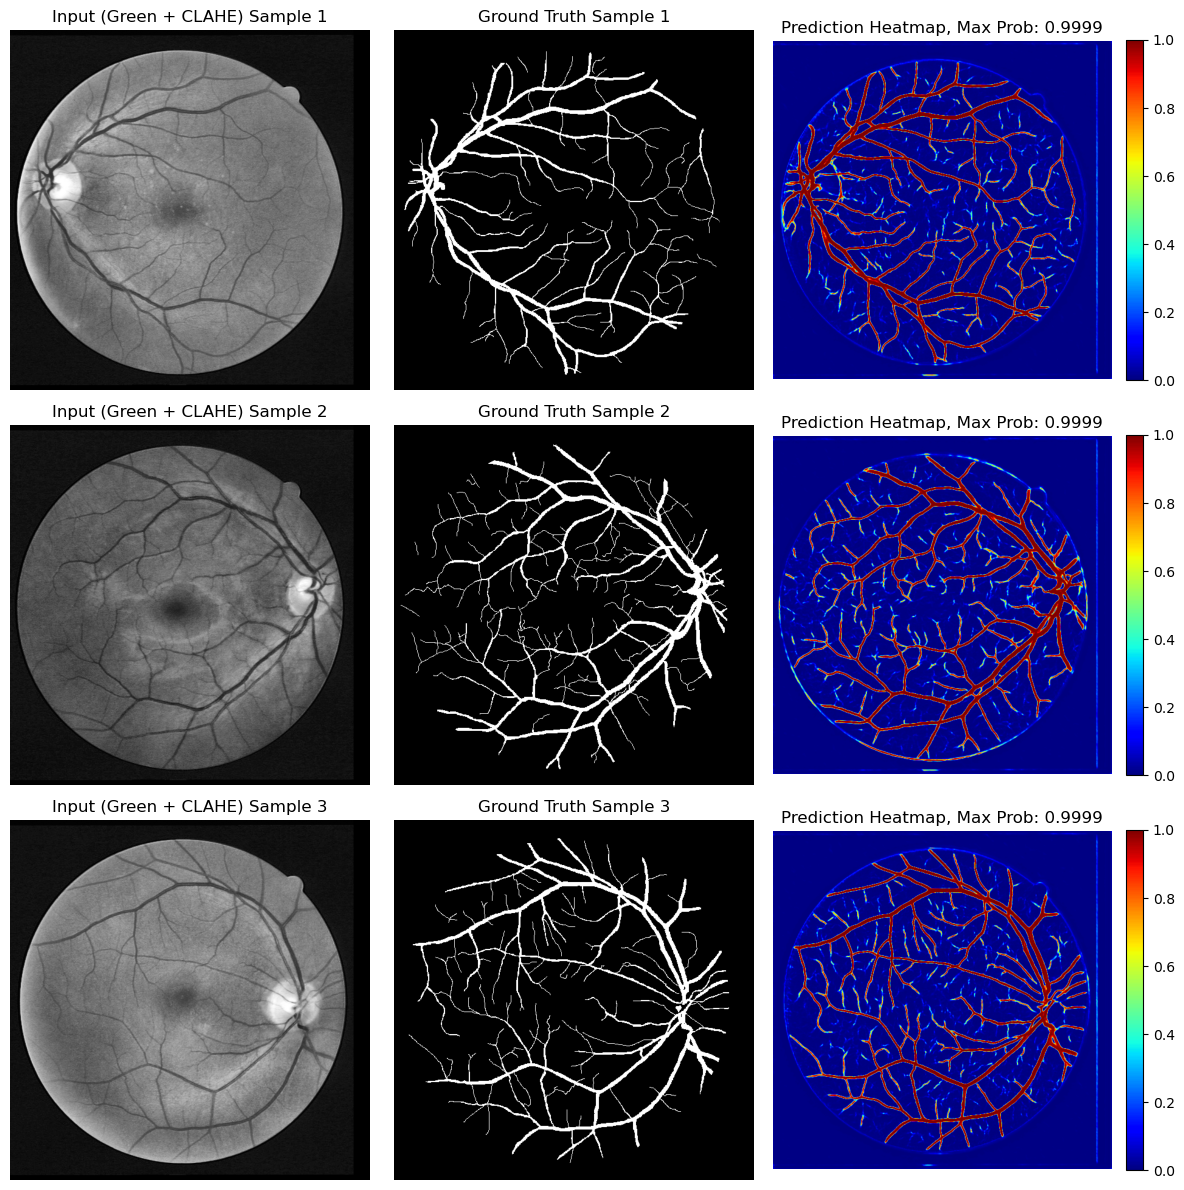

In [ ]:
NUM_SAMPLES = 3

plt.figure(figsize=(12, 4 * NUM_SAMPLES))

for i, (img_batch, mask_batch) in enumerate(val_dataset.take(NUM_SAMPLES)):
    
    # Model inference 
    pred_batch = model.predict(img_batch, verbose=0)
    
    # Batch: (1, H, W, 1) -> (H, W)
    img = img_batch[0, :, :, 0]
    mask = mask_batch[0, :, :, 0]
    pred = pred_batch[0, :, :, 0]
    
    # Subgraph (Input, Ground Truth, Prediction)
    ax1 = plt.subplot(NUM_SAMPLES, 3, i*3 + 1)
    ax2 = plt.subplot(NUM_SAMPLES, 3, i*3 + 2)
    ax3 = plt.subplot(NUM_SAMPLES, 3, i*3 + 3)
    
    # Plot 1
    ax1.imshow(img, cmap='gray')
    ax1.set_title(f'Input (Green + CLAHE) Sample {i+1}')
    ax1.axis('off')
    
    # Plot 2
    ax2.imshow(mask, cmap='gray')
    ax2.set_title(f'Ground Truth Sample {i+1}')
    ax2.axis('off')
    
    # Plot 3
    im = ax3.imshow(pred, cmap='jet', vmin=0.0, vmax=1.0)
    ax3.set_title(f'Prediction Heatmap, Max Prob: {pred.max():.4f}')
    ax3.axis('off')
    plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

隨後還是要做 Sanity Check

1. Mask Range 用來檢查 Ground Truth 是否符合 Loss Function 的預期格式。在這裡理應是 Binarized，所以應該在 [0, 1] 之間
2. Pred Range 用來檢查模型最後一層 Sigmoid 活化函數的輸出狀態，理想情況是接近 `[0.0000, 1.0000]`

In [35]:
print(f"Mask Range: [{mask.numpy().min()}, {mask.numpy().max()}]")
print(f"Pred Range: [{pred.min():.4f}, {pred.max():.4f}]")

Mask Range: [0.0, 1.0]
Pred Range: [0.0001, 0.9999]


如果 Pred Range 出現 `[0.4500, 0.5500]` 代表模型在瞎猜；如果是 `[nan, nan]` 或 `[0.0, 0.0]` 則是梯度爆炸、消失、或是 Overflow

## Section 5. Testing

**注意，課堂中的原始資料集沒有 Test Mask，因此從 [Source Dataset](https://www.kaggle.com/datasets/andrewmvd/drive-digital-retinal-images-for-vessel-extraction) 中取出 Test Mask。但因為原始資料集 Test Set 是拿來「交卷」跑 Kaggle Leaderboard，不是拿來「對答案」的，因此沒有辦法進行完整驗證。在這裡只做 DEMO**

**以下分數僅供參考**

### Step A. Dataset for Testing

這部分邏輯不變，先抓取檔案路徑

In [23]:
TEST_IMG_DIR = os.path.join(BASE_DIR, 'test_images')
TEST_MASK_DIR = os.path.join(BASE_DIR, 'test_masks')

test_img_paths, test_mask_paths = get_file_paths(TEST_IMG_DIR, TEST_MASK_DIR)

這裡可以直接用前面宣告過的 `validate_pipeline` 函數，因為測試跟驗證一樣，都要 Padding 到 592，不能切、不能轉、也不能調亮度

In [ ]:
test_dataset = tf.data.Dataset.from_tensor_slices((test_img_paths, test_mask_paths))
c
test_dataset = test_dataset.map(validate_pipeline, num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(1)
test_dataset = test_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

### Step B. Load the Pre-trained Model

現在就可以直接載入在 Section 3. Step E. 所訓練好的模型了。要注意這邊要填入前面的 Best Threshold

In [ ]:
MODEL_PATH = 'weighted_bce_dice_loss.h5'

custom_objs = {
    'dice_loss': dice_loss, 
    'dice_coef': dice_coef,
    'weighted_bce_dice_loss': weighted_bce_dice_loss
}

test_model = tf.keras.models.load_model(MODEL_PATH, custom_objects=custom_objs)

### Step C. Evaluation and Visualization

由於 `validate_pipeline` 有針對圖片做 $592 \times 592$ 的 Padding，所以模型輸出的預測圖也會帶有同樣的黑邊。那為了保持與 Validation 階段的評估基準一致，這裡就不進行反向 Crop，而是直接收集包含 Padding 區域的所有 pixel 的資料

同時 `sklearn` 的指標計算函數只接受 1D Array，所以在收集資料時，可以直接將 Mask 與 Prediction 壓平成 Numpy Array

In [ ]:
FINAL_THRESHOLD = 0.80 

test_masks_flat = []
test_preds_flat = []

for img_batch, mask_batch in test_dataset:

    # Inference the model
    pred_batch = test_model.predict(img_batch, verbose=0)

    # collect data and flatten
    test_masks_flat.extend(mask_batch.numpy().flatten())
    test_preds_flat.extend(pred_batch.flatten())

# Numpy Array
y_true = np.array(test_masks_flat).astype(int)
y_prob = np.array(test_preds_flat)

# Binarization
y_pred_binary = (y_prob > FINAL_THRESHOLD).astype(int)

最後就可以輸出成報告了

In [38]:
from sklearn.metrics import f1_score, jaccard_score, precision_score, recall_score, accuracy_score

dice = f1_score(y_true, y_pred_binary, zero_division=0)
iou = jaccard_score(y_true, y_pred_binary, zero_division=0)
precision = precision_score(y_true, y_pred_binary, zero_division=0)
recall = recall_score(y_true, y_pred_binary, zero_division=0)
acc = accuracy_score(y_true, y_pred_binary)

print(f"{'Metric':<15} | {'Value':<10}")
print("-" * 30)
print(f"{'Dice Score':<15} | {dice:.4f}")
print(f"{'IoU (Jaccard)':<15} | {iou:.4f}")
print(f"{'Precision':<15} | {precision:.4f}")
print(f"{'Recall':<15} | {recall:.4f}")
print(f"{'Accuracy':<15} | {acc:.4f}")

Metric          | Value     
------------------------------
Dice Score      | 0.2132
IoU (Jaccard)   | 0.1193
Precision       | 0.9991
Recall          | 0.1193
Accuracy        | 0.4297


最後輸出成圖像。注意這裡前三張圖與 Validation 階段相同，但 Test 階段會另外看 Binary Prediction

2026-01-14 22:28:06.357547: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


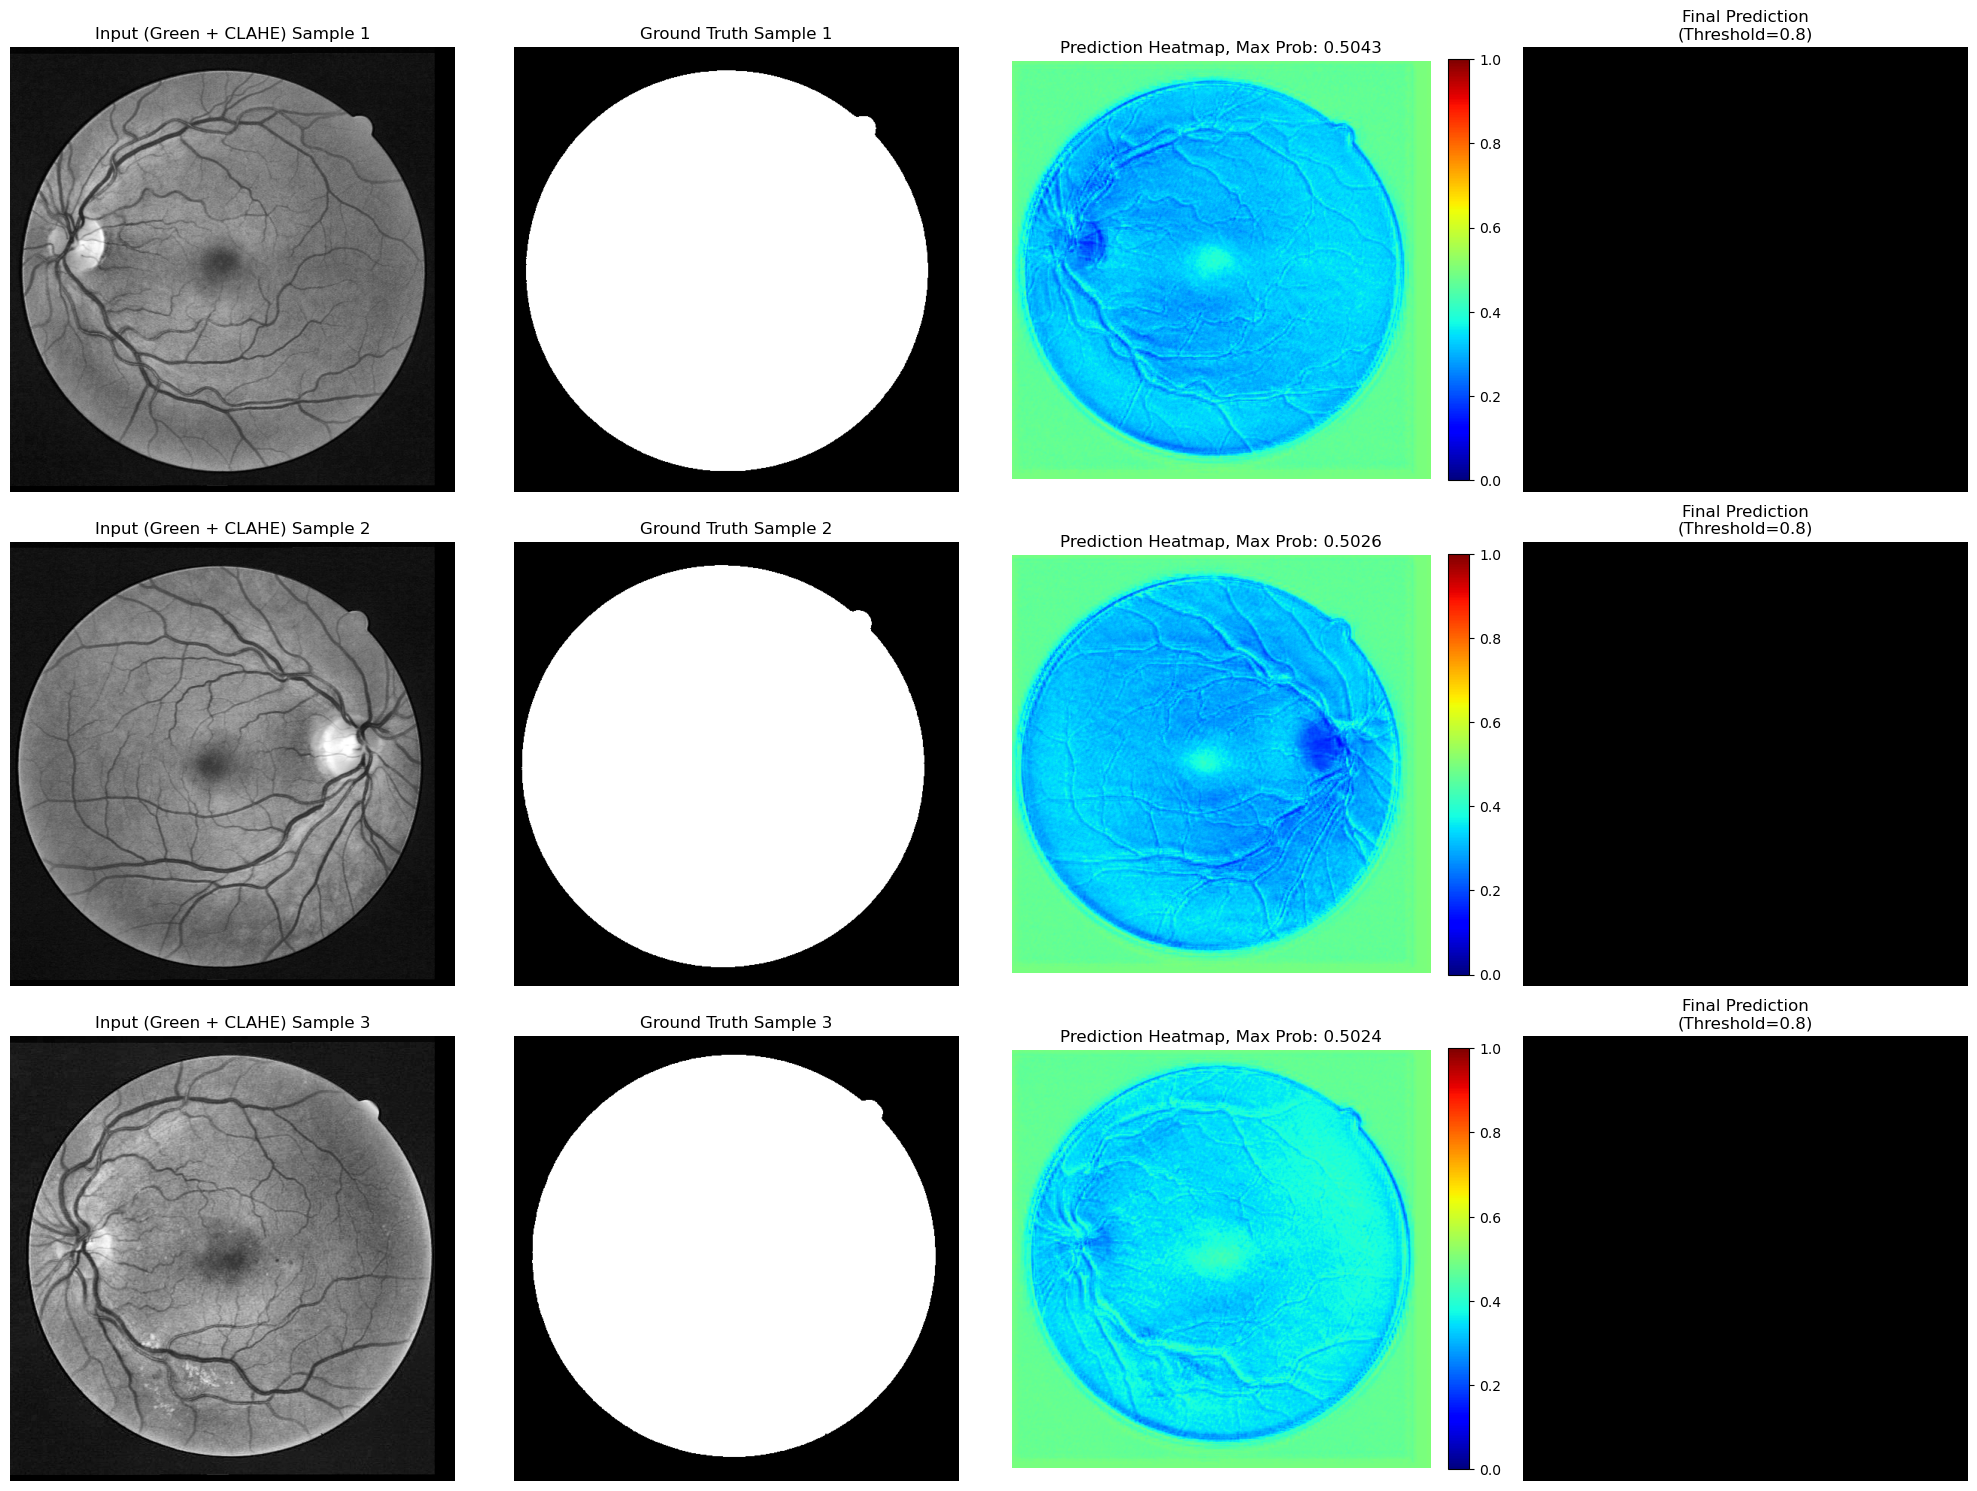

In [43]:
NUM_SAMPLES = 3

import matplotlib.pyplot as plt

plt.figure(figsize=(20, 5 * NUM_SAMPLES))

for i, (img_batch, mask_batch) in enumerate(test_dataset.take(NUM_SAMPLES)):

    # Model inference 
    pred_batch = model.predict(img_batch, verbose=0)

    # Batch: (1, H, W, 1) -> (H, W)
    img = img_batch[0, :, :, 0]
    mask = mask_batch[0, :, :, 0]
    pred = pred_batch[0, :, :, 0]
    pred_binary = (pred > FINAL_THRESHOLD).astype(int)

    # Subgraph (Input, Ground Truth, Prediction)
    ax1 = plt.subplot(NUM_SAMPLES, 4, i*4 + 1)
    ax2 = plt.subplot(NUM_SAMPLES, 4, i*4 + 2)
    ax3 = plt.subplot(NUM_SAMPLES, 4, i*4 + 3)
    ax4 = plt.subplot(NUM_SAMPLES, 4, i*4 + 4)

    # Plot 1
    ax1.imshow(img, cmap='gray')
    ax1.set_title(f'Input (Green + CLAHE) Sample {i+1}')
    ax1.axis('off')
    
    # Plot 2
    ax2.imshow(mask, cmap='gray')
    ax2.set_title(f'Ground Truth Sample {i+1}')
    ax2.axis('off')
    
    # Plot 3
    im = ax3.imshow(pred, cmap='jet', vmin=0.0, vmax=1.0)
    ax3.set_title(f'Prediction Heatmap, Max Prob: {pred.max():.4f}')
    ax3.axis('off')
    plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
    
    # Plot 4
    ax = plt.subplot(NUM_SAMPLES, 4, i*4 + 4)
    ax.imshow(pred_binary, cmap='gray')
    ax.set_title(f"Final Prediction\n(Threshold={FINAL_THRESHOLD})")
    ax.axis('off')

plt.tight_layout()
plt.show()

$$\text{Contents above are all for this assignment.} \quad \blacksquare$$